In [44]:
!hostname

node061


In [1]:
import pickle as pkl
import pandas as pd
import numpy as np
from pathlib import Path

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from src import util_analysis 
from src import util_process_prolific as util_process
import re

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


## Get participant data for current pipeline

In [2]:
#### Load in experiment manifests with full transcripts
parent_dir = Path("/om/user/imgriff/datasets/human_word_rec_SWC_2024/")
manifest = pd.read_pickle(parent_dir / "full_cue_target_distractor_df_w_meta_paths.pdpkl")

path_to_manifest = Path('/om/user/imgriff/datasets/human_word_rec_SWC_2024/full_cue_target_distractor_df_w_meta_transcripts.pdpkl')
df_w_transcripts = pd.read_pickle(path_to_manifest)

# unpack distractor words to individual columns

dist_1_word, dist_2_word = zip(*df_w_transcripts.distractor_word.apply(util_process.unpack_dist_words))

df_w_transcripts['distractor_1_word'] = dist_1_word
df_w_transcripts['distractor_2_word'] = dist_2_word
df_w_transcripts['targ_src_stem'] = df_w_transcripts.excerpt_src_fn.apply(util_process.slice_transcript_path)
df_w_transcripts['dist_1_src_stem'] = df_w_transcripts.excerpt_distractor_1_src_fn.apply(util_process.slice_transcript_path)
df_w_transcripts['dist_2_src_stem'] = df_w_transcripts.excerpt_distractor_2_src_fn.apply(util_process.slice_transcript_path)


def get_target_transcript(fname):
    return df_w_transcripts.loc[df_w_transcripts['targ_src_stem'].eq(fname), 'target_transcripts'].values[0]

def get_distractor_tscript(fname):
    if df_w_transcripts['dist_1_src_stem'].eq(fname).any():
        tscript = df_w_transcripts.loc[df_w_transcripts['dist_1_src_stem'].eq(fname), 'distractor_1_transcripts'].values[0]
    elif df_w_transcripts['dist_2_src_stem'].eq(fname).any():
        tscript = df_w_transcripts.loc[df_w_transcripts['dist_2_src_stem'].eq(fname), 'distractor_2_transcripts'].values[0]
    return tscript

def get_part_meta_dict(meta_file_name):
    part_manifest = pd.read_pickle(meta_file_name)
    records = []
    trial_ix_count = 0 
    for block_name, block in part_manifest.items():
        if isinstance(block, dict):
            for trial_ix, trial_dict in block.items():
                trial_dict['trial_num'] = trial_ix_count
                trial_dict['target_azimuth'] = trial_dict['target_loc'][0] 
                trial_dict['target_elev'] = trial_dict['target_loc'][1]
                trial_dict['distractor_azimuth'] = trial_dict['distractor_loc'][0]
                trial_dict['distractor_elev'] = trial_dict['distractor_loc'][1]
                trial_dict['block_name'] = block_name
                records.append(trial_dict)
                trial_ix_count += 1

        elif isinstance(block, list):
            for trial in block:
                trial['target_azimuth'] = trial['target_loc'][0]
                trial['target_elev'] = trial['target_loc'][1]
                trial['distractor_azimuth'] = trial['distractor_loc'][0]
                trial['distractor_elev'] = trial['distractor_loc'][1]
                trial['block_name'] = block_name
                trial['cue_fn'] = Path(trial['cue_fn'][0]).stem
                trial['target_fn'] = Path(trial['target_fn'][0]).stem
                trial['distractor_fn'] = Path(trial['distractor_fn'][0]).stem
                records.append(trial)
    

    meta_df = pd.DataFrame(records)
    meta_df.drop(columns=['target_loc', 'distractor_loc'], inplace=True)
    if 'global_trial_ix' in meta_df.columns:
        meta_df.rename(columns={'global_trial_ix': 'trial_num'}, inplace=True)
    return meta_df

def get_part_manifest(manifest_file_name):
    part_manifest = pd.read_pickle(manifest_file_name)
    records = []
    for ix, trial_manifest in enumerate(part_manifest):
        trial_dict = {}
        trial_dict['trial_num'] = ix
        # trial_dict['target_azimuth'] = trial_manifest[0][0]
        # trial_dict['target_elev'] = trial_manifest[0][1]
        # trial_dict['distractor_azimuth'] = trial_manifest[1][0]
        # trial_dict['distractor_elev'] = trial_manifest[1][1]
        # trial_dict['snr'] = trial_manifest[2]
        trial_dict['cue_fn'] = Path(trial_manifest[3][0]).stem
        trial_dict['target_fn'] = Path(trial_manifest[4][0]).stem
        trial_dict['distractor_fn'] = Path(trial_manifest[5][0]).stem

        records.append(trial_dict)
    manifest_df = pd.DataFrame(records)
    return manifest_df

In [3]:


# Add elev delta trials 
result_path = '/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/spotlight_v00/'
exp_manifest_path = '/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/speaker_array_manifests/spotlight_v00/'
part_results = sorted(list(Path(result_path).glob('*.csv')))
meta_files = sorted(list(Path(exp_manifest_path).glob('*meta.pkl')))
manifest_files = sorted(list(Path(exp_manifest_path).glob('*manifest.pkl')))

result_path_v1 = '/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/spotlight_v01/'
exp_manifest_path_v1 = '/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/speaker_array_manifests/spotlight_v01/'
part_results += sorted(list(Path(result_path_v1).glob('*.csv')))
meta_files += sorted(list(Path(exp_manifest_path_v1).glob('*meta.pkl')))
manifest_files += sorted(list(Path(exp_manifest_path_v1).glob('*manifest.pkl')))
# results += results
# manifests += manifests

# meta_files
manifest_dict = {}
meta_dict = {}

for meta_file in meta_files:
    if 'pilot' in meta_file.parent.stem:
        part_name = "pilot_" + "_".join(meta_file.stem.split('_')[:2])

    else:
        part_name = "_".join(meta_file.stem.split('_')[:2])
    if 'v01' in meta_file.parent.stem:
        part_name += '_v01'
    meta_dict[part_name] = meta_file

for manifest_file in manifest_files:
    if 'pilot' in manifest_file.parent.stem:
        part_name = "pilot_" + "_".join(manifest_file.stem.split('_')[:2])

    else:
        part_name = "_".join(manifest_file.stem.split('_')[:2])
    if 'v01' in manifest_file.parent.stem:
        part_name += '_v01'
    manifest_dict[part_name] = manifest_file

block_name_map = {
    'target_0': "block_front",
    'target_40': "block_fourty",
    'target_90': "block_ninety",
}

dfs = []
for result_file in part_results:
    try:
        part_name = result_file.stem
        # print(part_name)
        # remove space 
        if '000' in part_name:
            continue
        if 'pilot' in result_file.parent.stem:
            part_name = "pilot_" + "_".join(result_file.stem.split('_')[:2])
        if ' ' in part_name:
            part_name = part_name.split(' ')[0]
        if 'test' not in part_name: 
            part_ix = int(re.search(r'\d+', part_name).group())
            part_name_str = f"participant_{part_ix:03d}"
        if 'test' in part_name:
            continue
        if 'v01' in result_file.parent.stem:
            part_name_str += '_v01'

        meta_file = meta_dict[part_name_str]
        manifest_file = manifest_dict[part_name_str]
        part_df = util_process.get_part_df(result_file)
        meta_df = get_part_meta_dict(meta_file)
        manifest_df = get_part_manifest(manifest_file)
        # merge on shared trial_index
        part_df = pd.merge(part_df[['trial_num', 'response', 'correct_response', 'correct']],
                meta_df, left_on='trial_num', right_on='trial_num',)
        if 'cue_fn' not in part_df.columns:
            part_df = pd.merge(part_df, manifest_df, left_on='trial_num', right_on='trial_num')
        part_df['participant'] = part_name_str
        if part_df.block_name.str.contains('target').any():
            part_df['block_name'] = [block_name_map['_'.join(block.split('_')[:2])] for block in part_df.block_name]
        dfs.append(part_df)
    except Exception as e:
        print(e)
        print(result_file)
        continue

results_df = pd.concat(dfs, ignore_index=True)
results_df['abs_target_azim'] = results_df.target_azimuth.abs()
results_df['dist_transcripts'] = [util_process.get_distractor_tscript(fname, df_w_transcripts) for fname in results_df.distractor_fn.to_list()]
results_df['target_transcripts'] = [util_process.get_target_transcript(fname, df_w_transcripts) for fname in results_df.target_fn.to_list()]


cols_to_score = ['response', 'target_word', 'distractor_word', 'target_transcripts', 'dist_transcripts']

## add confusions 
correct = []
confusions = []
for response, target_word, distractor_word, target_transcripts, dist_transcripts in results_df[cols_to_score].to_numpy():
    correct.append(int(response == target_word or response in target_transcripts))
    confusions.append(int(response in dist_transcripts or response == distractor_word))

results_df['correct'] = correct
results_df['confusions'] = confusions

In [4]:
results_df['computed_azim_delta'] = np.abs(results_df['distractor_azimuth'] - results_df['target_azimuth'])

In [5]:

first_half = results_df.loc[results_df.trial_num < 180].copy()

# group data 

first_half_results_summary = first_half.groupby(['participant', 'block_name', 'azim_delta']).agg({'correct': ['mean', 'count'], 'confusions':['mean']}).reset_index()
# flatten multiindex
first_half_results_summary.columns = ['_'.join(col).strip() for col in first_half_results_summary.columns.values ]
# remove _ from end of each string
first_half_results_summary.columns = [col[:-1] if col[-1] == '_' else col for col in first_half_results_summary.columns]

In [6]:
# group data 

results_summary = results_df.groupby(['participant', 'block_name', 'azim_delta']).agg({'correct': ['mean', 'count'], 'confusions':['mean']}).reset_index()
# flatten multiindex
results_summary.columns = ['_'.join(col).strip() for col in results_summary.columns.values ]
# remove _ from end of each string
results_summary.columns = [col[:-1] if col[-1] == '_' else col for col in results_summary.columns]

In [7]:
results_summary.participant.unique()

array(['participant_001', 'participant_001_v01', 'participant_002_v01',
       'participant_003_v01', 'participant_004_v01',
       'participant_005_v01', 'participant_006', 'participant_006_v01',
       'participant_007', 'participant_007_v01', 'participant_008',
       'participant_008_v01', 'participant_009', 'participant_009_v01',
       'participant_010', 'participant_010_v01', 'participant_011',
       'participant_011_v01', 'participant_012_v01',
       'participant_013_v01', 'participant_014_v01',
       'participant_015_v01', 'participant_016_v01'], dtype=object)

Text(0.5, 1.0, 'First half of trials N=23 participants')

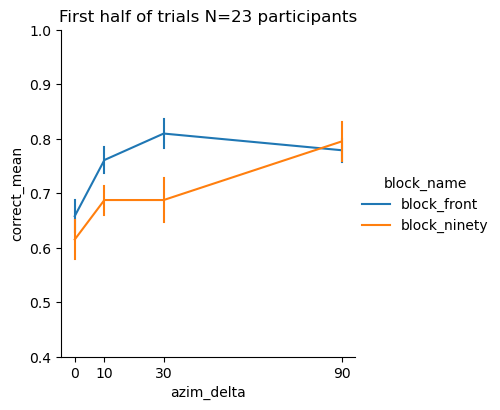

In [8]:
hue_order = ['block_front', 'block_ninety']
N = first_half_results_summary.participant.nunique()
g = sns.relplot(data=first_half_results_summary, x='azim_delta', y='correct_mean',
                 hue='block_name', hue_order=hue_order,
                 errorbar=('se', 1),err_style='bars',
                height=4,
                  kind='line', aspect=1)
# set xticks to be the same as the azimuth deltas
g.set(xticks=first_half_results_summary['azim_delta'].unique(), yticks=np.arange(0.4, 1.1, 0.1))
plt.title(f"First half of trials N={N} participants")

Text(0.5, 1.0, 'N=23 participants')

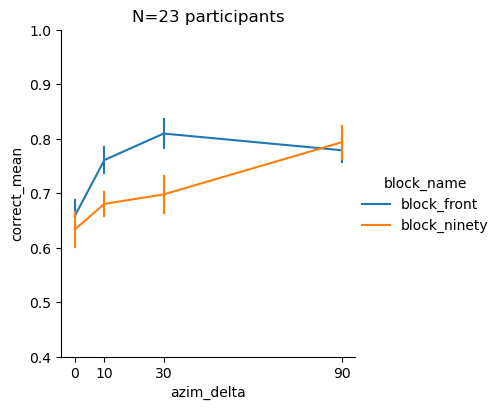

In [9]:
hue_order = ['block_front', 'block_ninety']
N = results_summary.participant.nunique()
g = sns.relplot(data=results_summary, x='azim_delta', y='correct_mean',
                 hue='block_name', hue_order=hue_order,
                 errorbar=('se', 1),err_style='bars',
                height=4,
                  kind='line', aspect=1)
# set xticks to be the same as the azimuth deltas
g.set(xticks=results_summary['azim_delta'].unique(), yticks=np.arange(0.4, 1.1, 0.1))
plt.title(f"N={N} participants")

Text(0.5, 1.0, 'N=23 participants')

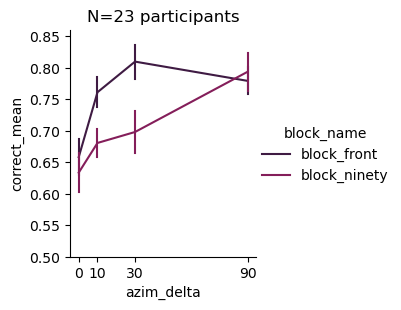

In [54]:
hue_order = ['block_front', 'block_fourty', 'block_ninety']
hue_order = ['block_front',  'block_ninety']
N = results_summary.participant.nunique()
cmap = sns.color_palette('rocket', n_colors=5)
palette = {target_azim: cmap[i] for i, target_azim in enumerate(['block_front', 'block_ninety'])}


g = sns.relplot(data=results_summary, x='azim_delta', y='correct_mean',
                 hue='block_name', hue_order=hue_order,
                 errorbar=('se', 1),err_style='bars',
                height=3,
                palette=palette,
                kind='line', aspect=1)
# set xticks to be the same as the azimuth deltas
g.set(xticks=results_summary['azim_delta'].unique(), yticks=np.arange(0.5, .86, 0.05), ylim=(0.5, 0.86))
plt.title(f"N={N} participants")

In [55]:
## Run ttest 
from scipy.stats import ttest_rel

for azim_delta in results_summary.azim_delta.unique():
    front = results_summary.loc[(results_summary['azim_delta'] == azim_delta) & (results_summary['block_name'] == 'block_front'), 'correct_mean']
    ninety = results_summary.loc[(results_summary['azim_delta'] == azim_delta) & (results_summary['block_name'] == 'block_ninety'), 'correct_mean']
    t, p = ttest_rel(front, ninety)
    print(f"t={t}, p={p}, azim_delta={azim_delta}")

t=0.5650068998934183, p=0.5777857661921234, azim_delta=0
t=3.2903512774948367, p=0.003337573569818838, azim_delta=10
t=4.211956663541645, p=0.0003595428187510328, azim_delta=30
t=-0.510416106536451, p=0.6148433891946763, azim_delta=90


### Run stats (2-way ANOVA)

In [56]:
to_anova = results_summary[results_summary.block_name != 'block_fourty'].copy()
to_anova.rename(columns={'block_name': 'target_azim', "azim_delta":'distractor_offset'}, inplace=True)

In [57]:
# import statsmodels.api as sm
# import statsmodels.formula.api as smf

# from statsmodels.formula.api import ols
# from scipy.stats import f
# from statsmodels.stats.anova import AnovaRM


In [58]:
to_anova

,participant,target_azim,distractor_offset,correct_mean,correct_count,confusions_mean
4,participant_001,block_front,0,0.65,20,0.05
5,participant_001,block_front,10,0.65,20,0.00
6,participant_001,block_front,30,0.80,20,0.00
7,participant_001,block_front,90,0.95,20,0.00
8,participant_001,block_ninety,0,0.85,20,0.00
...,...,...,...,...,...,...
207,participant_016_v01,block_front,90,0.60,20,0.05
208,participant_016_v01,block_ninety,0,0.55,20,0.05
209,participant_016_v01,block_ninety,10,0.60,20,0.15
210,participant_016_v01,block_ninety,30,0.60,20,0.05


In [59]:
my_model_fit = AnovaRM(to_anova, 'correct_mean', 'participant', within=['target_azim', 'distractor_offset']).fit()
print(my_model_fit.anova_table)

NameError: name 'AnovaRM' is not defined

## Plot human and model together

In [24]:
# ## import experiment word map
# human_exp_word_key = pickle.load( open(path_to_expmt_stim / "human_azim_spotlight_word_key.pkl", "rb" )) 
# exp_word_2_class = {v:k for k,v in human_exp_word_key.items()}

In [25]:
# Path to results 

cols_to_merge = ['stim_name',
                 'word',
                 'sex_cond',
                 'target_transcripts',
                 'distractor_transcripts',
                 'distractor_word',

]

# output_paths = list(Path("binaural_eval/word_task_voice_loc_cue_only_v04").glob("*.pkl")) old path for more locations
import pickle
# match human pilot conditions
# model_name = 'word_task_half_co_loc_v06'
# output_paths = list(Path(f"binaural_eval/sim_azim_spotlight_v02/").glob("*/*.pkl"))
output_paths = list(Path(f"binaural_eval/sim_azim_spotlight_v02_min_reverb_room1004_30dB_pink_noise_bg/").glob("*/*.pkl"))

word_class_map = pickle.load( open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_800_word_label_to_int_dict.pkl", "rb" )) 
ix_to_word = {v:k for k,v in word_class_map.items()}

remap_azim = lambda azim: 360 - azim if azim > 180 else 0 - azim 

results_dfs = []

model_name_dict = {
                   "word_task_half_co_loc_v09_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout": 'Feature-gain Model',
                   "word_task_v10_main_feature_gain_config": 'Feature-gain Model'
                  }


gend_map = {True:'same', False:'diff'}

for path in output_paths:
    if not any(name in str(path) for name in ['word_task_v10_main_feature_gain_config']):# 'word_task_half_co_loc_v08']):
        continue

    # res_dict = pickle.load(open(path, 'rb'))
    try:
        df = pd.DataFrame(pd.read_pickle(path))
    
        df['response'] = df['preds'].replace(ix_to_word)
        df['true_word'] = df['true_word_int'].replace(ix_to_word)
        # df['confusions'] = (df.response == df.distractor_word).astype('int')
        # df['accuracy'] = (df.response == df.word).astype('int')


        # # add adjusted accuracy and confusions 
        # pred_words = df.response.values
        # target_words = df.word.values
        # target_transcripts = df.target_transcripts.values
        # distractor_words = df.distractor_word.values
        # distractor_transcripts = df.distractor_transcripts.values


        # adjusted_acc = np.array([int(pred_word in target_transcript or pred_word == target_word)
        #                             if not isinstance(target_transcript, float) else np.nan
        #                             for pred_word, target_word, target_transcript in zip(pred_words, target_words, target_transcripts)
        #                             ])

        # adjusted_confs = np.array([int(pred_word in distractor_transcript or pred_word == dist_word)
        #                             if not (isinstance(distractor_transcript, float)) else np.nan
        #                             for pred_word, dist_word, distractor_transcript in zip(pred_words, distractor_words,  distractor_transcripts)
        #                             ])

        # df['accuracy'] = adjusted_acc
        # df['confusions'] = adjusted_confs
        df.rename(columns={"results": "accuracy"}, inplace=True)

        df['target_azim'] = int(re.search('target_loc_(-?\d+)', path.stem).group(0).strip('target_loc_'))
        df['distractor_azim'] = int(re.search('distract_loc_(-?\d+)', path.stem).group(0).strip('distract_loc_'))
        df['target_azim'] = df['target_azim'].apply(remap_azim)
        df['distractor_azim'] = df['distractor_azim'].apply(remap_azim)
        
        
        # df.rename(columns={"results": "accuracy"}, inplace=True)
        df['model'] = model_name_dict[path.parent.stem]
        results_dfs.append(df)
    except Exception as error:
        print(error)
        print(path)
        continue


model_results = pd.concat(results_dfs)


In [26]:
path

PosixPath('binaural_eval/sim_azim_spotlight_v02_min_reverb_room1004_30dB_pink_noise_bg/word_task_v10_main_feature_gain_config/word_task_v10_main_feature_gain_config_target_loc_90_0_distract_loc_90_0_0_SNR_single_distractor_30dB_pink_noise_bg_min_reverb_room0000_all_stim.pkl')

In [27]:
model_results.target_azim.abs().unique(), model_results.distractor_azim.abs().unique()

(array([ 0, 90]), array([ 0, 10, 90, 30, 80, 60]))

In [28]:
## Get and format model data for merging with human data
model_to_merge = model_results.copy()
model_to_merge['target_azim'] = model_to_merge['target_azim'].abs()
model_to_merge['distractor_azim'] = model_to_merge['distractor_azim'].abs()
model_to_merge['azim_delta'] = np.abs(model_to_merge['distractor_azim'] - model_to_merge['target_azim'])
model_to_merge = model_to_merge[model_to_merge['azim_delta'].isin([0, 10, 30, 90])]
model_to_merge['group'] = model_to_merge['model']
model_to_merge.rename(columns={'target_azim':'Target azimuth'}, inplace=True)
# same for human data
human_to_merge = results_summary[results_summary.block_name != 'block_fourty'].copy().reset_index(drop=True)
human_to_merge.rename(columns={'block_name': 'Target azimuth', 'correct_mean':'accuracy', 'confusions_mean':'confusions'}, inplace=True)
# rename values in column target azimuth 
human_to_merge['Target azimuth'] = human_to_merge['Target azimuth'].replace({'block_front': 0, 'block_ninety': 90})
N = human_to_merge.participant.nunique()
human_to_merge["group"] = f"Humans (N={N})"

# merge 
merged_df = pd.concat([model_to_merge, human_to_merge], ignore_index=True)
merged_df.dropna(axis=1, inplace=True)
merged_df['azim_delta'] = merged_df['azim_delta'].astype(int)
merged_df['Target azimuth'] = merged_df['Target azimuth'].astype(int)

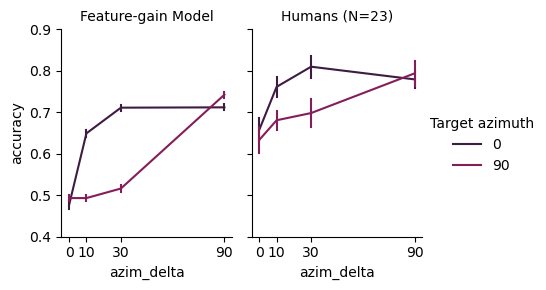

In [ ]:
hue_order = [0,  90]

cmap = sns.color_palette('rocket', n_colors=5)
palette = {target_azim: cmap[i] for i, target_azim in enumerate([0, 90])}


g = sns.relplot(data=merged_df, x='azim_delta', y='accuracy',
                 hue='Target azimuth', hue_order=hue_order,
                 col='group',
                 errorbar=('se', 1),err_style='bars',
                height=3,
                palette=palette,
                kind='line', aspect=0.75)
# set xticks to be the same as the azimuth deltas
g.set(xticks=results_summary['azim_delta'].unique(), yticks=np.arange(0.40, .91, 0.1))
g.set_titles("{col_name}")
# plt.title(f"N={N} participants")

## Look at each participants data

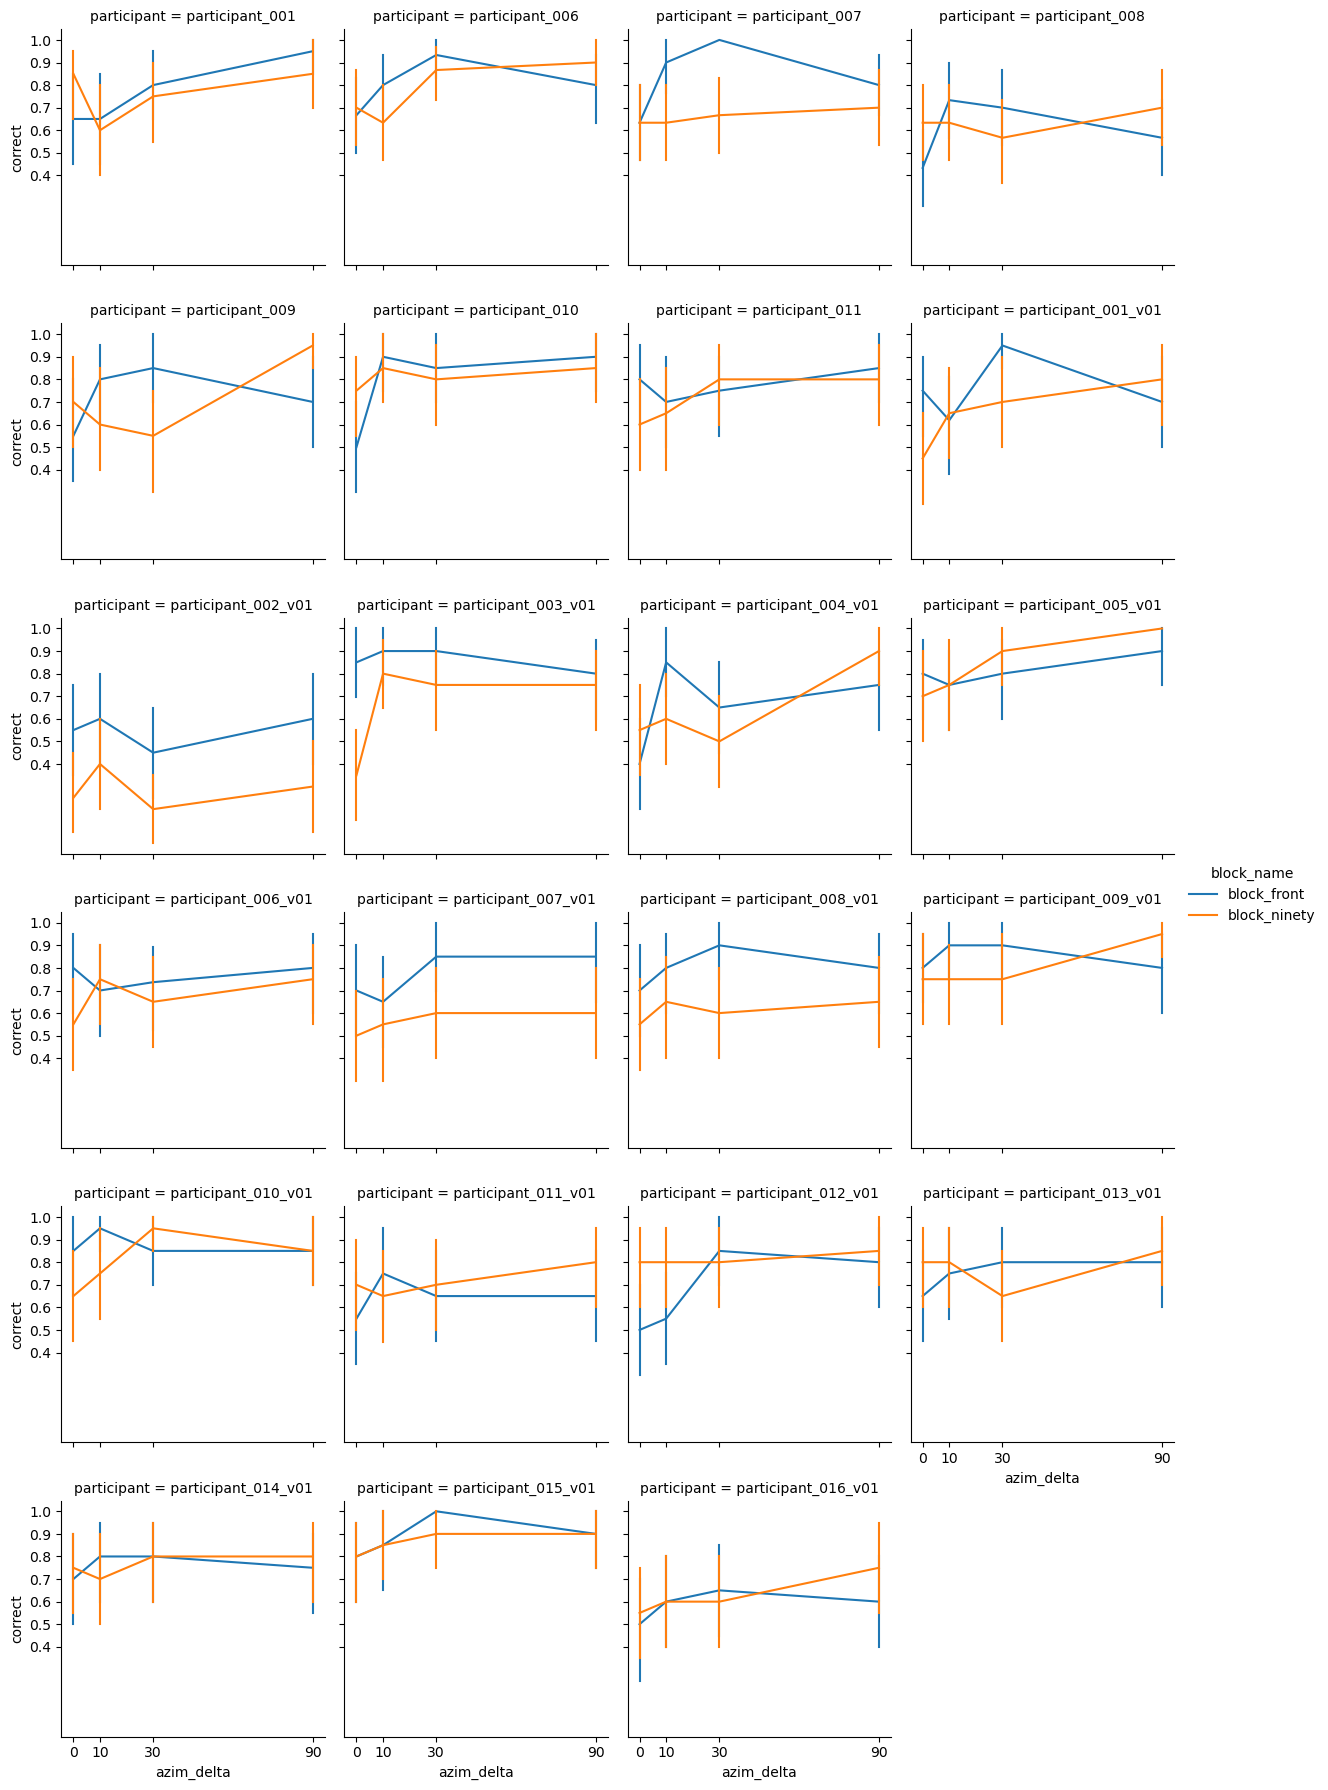

In [23]:
hue_order = ['block_front',  'block_ninety']
g = sns.relplot(data=results_df, x='azim_delta', y='correct',
                 hue='block_name',hue_order=hue_order,
                err_style='bars',
                 col='participant', col_wrap=4,
                height=3,
                  kind='line', aspect=1)
# set xticks to be the same as the azimuth deltas
g.set(xticks=results_summary['azim_delta'].unique(), yticks=np.arange(0.4, 1.1, 0.1))

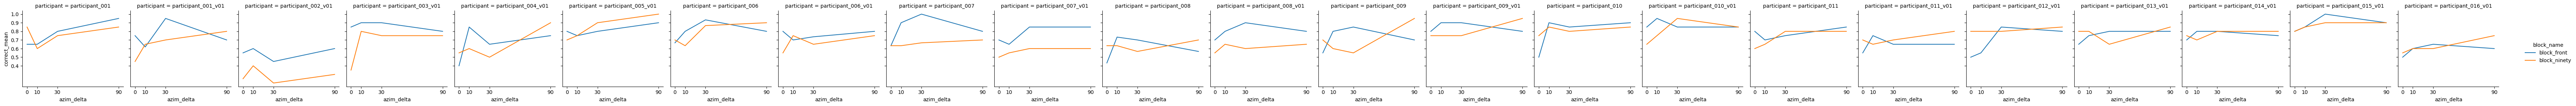

In [24]:
g = sns.relplot(data=results_summary, x='azim_delta', y='correct_mean',
                 hue='block_name', hue_order=hue_order,
                err_style='bars',
                 col='participant',
                height=3,
                  kind='line', aspect=1)
# set xticks to be the same as the azimuth deltas
g.set(xticks=results_summary['azim_delta'].unique(), yticks=np.arange(0.4, 1.1, 0.1))

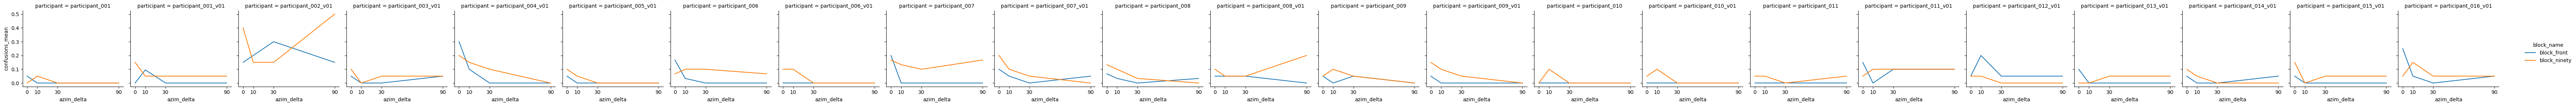

In [25]:
g = sns.relplot(data=results_summary, x='azim_delta', y='confusions_mean', 
                hue='block_name', hue_order=hue_order,
                 errorbar=('se', 1),err_style='bars',
                 col='participant',
                 height=3,
                  kind='line', aspect=1)
# set xticks to be the same as the azimuth deltas
g.set(xticks=results_summary['azim_delta'].unique())